# Pré-processamento

Carregamento das bases de treino, validação e teste geradas na etapa anterior.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

In [51]:
DADOS_INTERIM = Path.cwd().parent / 'data' / 'interim'

X_train = pd.read_parquet(DADOS_INTERIM / 'X_train.parquet')
y_train = pd.read_parquet(DADOS_INTERIM / 'y_train.parquet').squeeze('columns')

X_val = pd.read_parquet(DADOS_INTERIM / 'X_val.parquet')
y_val = pd.read_parquet(DADOS_INTERIM / 'y_val.parquet').squeeze('columns')

X_test = pd.read_parquet(DADOS_INTERIM / 'X_test.parquet')
y_test = pd.read_parquet(DADOS_INTERIM / 'y_test.parquet').squeeze('columns')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape} | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape} | y_test:  {y_test.shape}')

X_train: (196806, 105) | y_train: (196806,)
X_val:   (49202, 105) | y_val:   (49202,)
X_test:  (61503, 105) | y_test:  (61503,)


In [55]:
import numpy as np

CATEGORICAS_FORCADAS = []
NUMERICAS_FORCADAS = []

def separar_variaveis(df, categoricas_forcadas=None, numericas_forcadas=None):
    """Retorna listas mutuamente exclusivas de colunas categóricas e numéricas."""
    categoricas_forcadas = set(categoricas_forcadas or [])
    numericas_forcadas = set(numericas_forcadas or [])

    colunas_invalidas = (categoricas_forcadas | numericas_forcadas) - set(df.columns)
    if colunas_invalidas:
        raise KeyError(f'Colunas não encontradas: {sorted(colunas_invalidas)}')
    if categoricas_forcadas & numericas_forcadas:
        raise ValueError('Uma coluna não pode ser forçada como categórica e numérica ao mesmo tempo.')

    categoricas = set(
        df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns
    )
    numericas = set(df.select_dtypes(include=[np.number]).columns)

    categoricas = (categoricas - numericas_forcadas) | categoricas_forcadas
    numericas = (numericas - categoricas_forcadas) | numericas_forcadas

    nao_classificadas = set(df.columns) - categoricas - numericas
    if nao_classificadas:
        raise TypeError(
            'Há colunas com dtype não classificado. Defina-as em uma das listas de exceção: '
            f'{sorted(nao_classificadas)}'
        )

    categoricas = sorted(categoricas)
    numericas = sorted(numericas)

    assert not (set(categoricas) & set(numericas))
    assert set(categoricas) | set(numericas) == set(df.columns)
    return categoricas, numericas

variaveis_categoricas, variaveis_numericas = separar_variaveis(
    X_train,
    categoricas_forcadas=CATEGORICAS_FORCADAS,
    numericas_forcadas=NUMERICAS_FORCADAS,
)

print(f'Variáveis categóricas: {len(variaveis_categoricas)}')
print(f'Variáveis numéricas: {len(variaveis_numericas)}')
print('Total de colunas classificadas:', len(variaveis_categoricas) + len(variaveis_numericas))

Variáveis categóricas: 15
Variáveis numéricas: 90
Total de colunas classificadas: 105


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder


def criar_preprocessador(
    variaveis_numericas,
    variaveis_categoricas,
):
    """Cria o pipeline de pré-processamento."""

    pipeline_numerico = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )

    pipeline_categorico = Pipeline(
        steps=[
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]
    )

    preprocessador = (
        ColumnTransformer(
            transformers=[
                (
                    "numericas",
                    pipeline_numerico,
                    variaveis_numericas,
                ),
                (
                    "categoricas",
                    pipeline_categorico,
                    variaveis_categoricas,
                ),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )
        .set_output(transform="pandas")
    )

    return preprocessador

In [57]:
preprocessador = criar_preprocessador(
    variaveis_numericas=variaveis_numericas,
    variaveis_categoricas=variaveis_categoricas,
)

X_train_processado = preprocessador.fit_transform(X_train)
X_val_processado = preprocessador.transform(X_val)
X_test_processado = preprocessador.transform(X_test)

### Seleção de variáveis

A técnica que será usado para reduzir mais as variáveis se chama, RFECV (Recursive Feature Elimination With Cross-Validation) é um método de seleção automática de variáveis que combina:

- RFE (Recursive Feature Elimination): remove iterativamente as variáveis menos importantes.
- Validação cruzada: Avalia o desempenho do modelo em cada etapa para encontrar automaticamente o melhor número de variáveis.

In [21]:
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np
import copy


def calcular_importancia_e_score_cv(
    modelo,
    X,
    y,
    variaveis,
    n_splits=5,
    n_repeats=5,
    random_state=42,
):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    importancias = []
    scores = []


    for train_idx, val_idx in skf.split(X, y):

        X_tr = X.iloc[train_idx][variaveis]
        X_fold_val = X.iloc[val_idx][variaveis]

        y_tr = y.iloc[train_idx]
        y_fold_val = y.iloc[val_idx]


        modelo_cv = clone(modelo)

        modelo_cv.fit(
            X_tr,
            y_tr
        )


        y_prob = modelo_cv.predict_proba(
            X_fold_val
        )[:,1]


        pr_auc = average_precision_score(
            y_fold_val,
            y_prob
        )

        scores.append(pr_auc)


        resultado = permutation_importance(
            estimator=modelo_cv,
            X=X_fold_val,
            y=y_fold_val,
            scoring="average_precision",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )


        importancias.append(
            resultado.importances_mean
        )


    return (
        pd.Series(
            np.mean(importancias, axis=0),
            index=variaveis
        ).sort_values(),

        np.mean(scores),

        np.std(scores)
    )


def selecionar_variaveis(
    modelo,
    X_train,
    y_train,
    step=0.05,
    min_features=20,
    n_splits=5,
    n_repeats=5,
    random_state=42,
):

    variaveis = list(X_train.columns)

    historico = []


    while len(variaveis) >= min_features:


        importancias, pr_auc, std_auc = (
            calcular_importancia_e_score_cv(
                modelo=modelo,
                X=X_train,
                y=y_train,
                variaveis=variaveis,
                n_splits=n_splits,
                n_repeats=n_repeats,
                random_state=random_state,
            )
        )


        print(
            f"{len(variaveis):3d} variáveis | "
            f"PR AUC={pr_auc:.5f} ± {std_auc:.5f}"
        )


        historico.append({
            "n_variaveis": len(variaveis),
            "pr_auc": pr_auc,
            "std_pr_auc": std_auc,
            "variaveis": variaveis.copy()
        })


        quantidade_remover = max(
            1,
            int(len(variaveis) * step)
        )


        variaveis = importancias.index[
            quantidade_remover:
        ].tolist()


    return (
        variaveis,
        pd.DataFrame(historico)
    )

In [22]:
modelo = LGBMClassifier(
    n_estimators=550,
    learning_rate=0.03,
    num_leaves=51,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

In [23]:
melhores_variaveis, historico = selecionar_variaveis(
    modelo=modelo,
    X_train=X_train_processado,
    y_train=y_train,
    step=0.05,
    min_features=20,
    n_splits=3,
    n_repeats=3,
)

105 variáveis | PR AUC=0.23803 ± 0.00303
100 variáveis | PR AUC=0.23652 ± 0.00270
 95 variáveis | PR AUC=0.23677 ± 0.00267
 91 variáveis | PR AUC=0.23717 ± 0.00296
 87 variáveis | PR AUC=0.23843 ± 0.00299
 83 variáveis | PR AUC=0.23897 ± 0.00339
 79 variáveis | PR AUC=0.23723 ± 0.00240
 76 variáveis | PR AUC=0.23793 ± 0.00312
 73 variáveis | PR AUC=0.23894 ± 0.00184
 70 variáveis | PR AUC=0.23723 ± 0.00166
 67 variáveis | PR AUC=0.23786 ± 0.00263
 64 variáveis | PR AUC=0.23829 ± 0.00213
 61 variáveis | PR AUC=0.23875 ± 0.00367
 58 variáveis | PR AUC=0.23775 ± 0.00161
 56 variáveis | PR AUC=0.23820 ± 0.00173
 54 variáveis | PR AUC=0.23884 ± 0.00265
 52 variáveis | PR AUC=0.23856 ± 0.00374
 50 variáveis | PR AUC=0.23737 ± 0.00165
 48 variáveis | PR AUC=0.23774 ± 0.00257
 46 variáveis | PR AUC=0.23899 ± 0.00232
 44 variáveis | PR AUC=0.23817 ± 0.00229
 42 variáveis | PR AUC=0.23857 ± 0.00189
 40 variáveis | PR AUC=0.23819 ± 0.00259
 38 variáveis | PR AUC=0.23821 ± 0.00247
 37 variáveis | 

In [35]:
melhor_idx = historico["pr_auc"].idxmax()

melhores_variaveis = historico.loc[
    melhor_idx,
    "variaveis"
]

print(len(melhores_variaveis))
print(melhores_variaveis)

46
['FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_15', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_13', 'FLAG_EMP_PHONE', 'REG_REGION_NOT_LIVE_REGION', 'DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_18', 'YEARS_BEGINEXPLUATATION_AVG', 'FLAG_DOCUMENT_16', 'LIVINGAPARTMENTS_AVG', 'DEF_30_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'REGION_POPULATION_RELATIVE', 'TOTALAREA_MODE', 'BASEMENTAREA_AVG', 'REG_CITY_NOT_LIVE_CITY', 'CNT_FAM_MEMBERS', 'AMT_REQ_CREDIT_BUREAU_QRT', 'FLAG_WORK_PHONE', 'NAME_INCOME_TYPE', 'ORGANIZATION_TYPE', 'AMT_INCOME_TOTAL', 'REGION_RATING_CLIENT_W_CITY', 'NAME_FAMILY_STATUS', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_3', 'NAME_CONTRACT_TYPE', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'OCCUPATION_TYPE', 'OWN_CAR_AGE', 'EXT_SOURCE_2', 'NAME_EDUCATION_TYPE', 'EXT_SOURCE_COMPLT_SUM', 'EXT_SOURCE_1', 'DAYS_EMPLOYED', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_3', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'EXT_SOURCE_COMPLT_MEAN']


In [58]:
melhores_variaveis = [
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_15",
    "FLAG_CONT_MOBILE",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_13",
    "FLAG_EMP_PHONE",
    "REG_REGION_NOT_LIVE_REGION",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "FLAG_DOCUMENT_18",
    "YEARS_BEGINEXPLUATATION_AVG",
    "FLAG_DOCUMENT_16",
    "LIVINGAPARTMENTS_AVG",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "REGION_POPULATION_RELATIVE",
    "TOTALAREA_MODE",
    "BASEMENTAREA_AVG",
    "REG_CITY_NOT_LIVE_CITY",
    "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "FLAG_WORK_PHONE",
    "NAME_INCOME_TYPE",
    "ORGANIZATION_TYPE",
    "AMT_INCOME_TOTAL",
    "REGION_RATING_CLIENT_W_CITY",
    "NAME_FAMILY_STATUS",
    "DAYS_LAST_PHONE_CHANGE",
    "FLAG_DOCUMENT_3",
    "NAME_CONTRACT_TYPE",
    "DAYS_ID_PUBLISH",
    "DAYS_REGISTRATION",
    "OCCUPATION_TYPE",
    "OWN_CAR_AGE",
    "EXT_SOURCE_2",
    "NAME_EDUCATION_TYPE",
    "EXT_SOURCE_COMPLT_SUM",
    "EXT_SOURCE_1",
    "DAYS_EMPLOYED",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "EXT_SOURCE_3",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_COMPLT_MEAN",
]

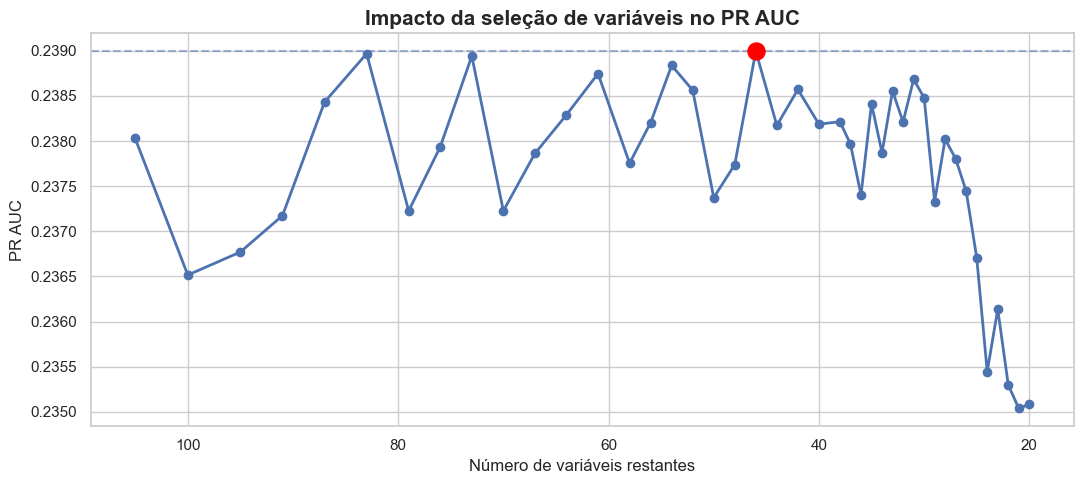

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(11, 5))


# linha principal
ax.plot(
    historico["n_variaveis"],
    historico["pr_auc"],
    marker="o",
    linewidth=2,
    markersize=6
)


# melhor ponto
melhor_idx = historico["pr_auc"].idxmax()

melhor_n = historico.loc[melhor_idx, "n_variaveis"]
melhor_pr = historico.loc[melhor_idx, "pr_auc"]


ax.scatter(
    melhor_n,
    melhor_pr,
    s=150,
    color="red",
    zorder=5
)


# linha horizontal no melhor PR AUC
ax.axhline(
    melhor_pr,
    linestyle="--",
    alpha=0.5
)


# eixo decrescente de variáveis
ax.invert_xaxis()


ax.set_title(
    "Impacto da seleção de variáveis no PR AUC",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel(
    "Número de variáveis restantes"
)

ax.set_ylabel(
    "PR AUC"
)


plt.tight_layout()
plt.show()

In [59]:
X_train_processado = X_train_processado[melhores_variaveis]
X_val_processado = X_val_processado[melhores_variaveis]
X_test_processado = X_test_processado[melhores_variaveis]

### Modelagem

In [60]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


def criar_modelos(y_train):

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

    modelos = {

        "Random Forest": RandomForestClassifier(
            n_estimators=1000,
            criterion="gini",
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),

        "LightGBM": LGBMClassifier(
            objective="binary",
            boosting_type="gbdt",

            n_estimators=750,
            learning_rate=0.03,

            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,

            subsample=0.8,
            subsample_freq=1,

            colsample_bytree=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            scale_pos_weight=scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbose=-1,
        ),

        "XGBoost": XGBClassifier(
            objective="binary:logistic",

            n_estimators=600,
            learning_rate=0.03,

            max_depth=7,
            min_child_weight=5,
            gamma=0.1,

            subsample=0.8,
            colsample_bytree=0.8,
            colsample_bylevel=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            scale_pos_weight=scale_pos_weight,

            eval_metric="logloss",

            random_state=42,
            n_jobs=-1,
        ),
    }

    return modelos

In [61]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)


def calcular_metricas(y_true, y_pred, y_prob):
    """Calcula as métricas de classificação."""

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_SCORE": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "KS": ks,
    }

In [62]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
import pandas as pd


def avaliar_modelos_cv(
    X,
    y,
    modelos,
    n_splits=3,
):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    resultados = []

    for nome, modelo_base in modelos.items():

        for idx_train, idx_val in cv.split(X, y):

            X_train_fold = X.iloc[idx_train]
            X_val_fold = X.iloc[idx_val]

            y_train_fold = y.iloc[idx_train]
            y_val_fold = y.iloc[idx_val]

            modelo = clone(modelo_base)

            # Atualiza o balanceamento apenas para modelos compatíveis
            if "scale_pos_weight" in modelo.get_params():

                scale_pos_weight = (
                    (y_train_fold == 0).sum()
                    /
                    (y_train_fold == 1).sum()
                )

                modelo.set_params(
                    scale_pos_weight=scale_pos_weight
                )

            modelo.fit(
                X_train_fold,
                y_train_fold,
            )

            y_pred = modelo.predict(X_val_fold)
            y_prob = modelo.predict_proba(X_val_fold)[:, 1]

            metricas = calcular_metricas(
                y_true=y_val_fold,
                y_pred=y_pred,
                y_prob=y_prob,
            )

            resultados.append({
                "Modelo": nome,
                **metricas,
            })

    resultados = pd.DataFrame(resultados)

    resumo = (
        resultados
        .groupby("Modelo")
        .agg(
            Precision_Mean=("Precision", "mean"),
            Precision_STD=("Precision", "std"),
            Recall_Mean=("Recall", "mean"),
            Recall_STD=("Recall", "std"),
            F1_Mean=("F1_SCORE", "mean"),
            F1_STD=("F1_SCORE", "std"),
            ROC_AUC_Mean=("ROC_AUC", "mean"),
            ROC_AUC_STD=("ROC_AUC", "std"),
            PR_AUC_Mean=("PR_AUC", "mean"),
            PR_AUC_STD=("PR_AUC", "std"),
            KS_Mean=("KS", "mean"),
            KS_STD=("KS", "std"),
        )
        .round(4)
        .reset_index()
    )

    return resumo

In [63]:
# Cria o dicionário de modelos
modelos = criar_modelos(y_train)

Scale Pos Weight: 11.39


In [64]:
import os

import mlflow
import pandas as pd

from sklearn.base import clone


mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI","http://localhost:5000"))
mlflow.set_experiment("models-cross-val")

resumos = []

with mlflow.start_run(run_name="cross-validation"):

    mlflow.set_tag("stage","model_selection")
    mlflow.set_tag("metric","PR_AUC")
    mlflow.log_param("n_splits",3)
    mlflow.log_param("n_features",X_train_processado.shape[1])

    for nome_modelo, modelo in modelos.items():

        with mlflow.start_run(run_name=nome_modelo,nested=True,):

            modelo_cv = clone(modelo)

            resumo = avaliar_modelos_cv(
                X=X_train_processado,
                y=y_train,
                modelos={
                    nome_modelo: modelo_cv
                },
                n_splits=3,
            )

            linha = resumo.iloc[0]

            mlflow.log_param("algorithm",nome_modelo)

            mlflow.log_metrics({

                "precision_mean": float(linha["Precision_Mean"]),
                "precision_std": float(linha["Precision_STD"]),

                "recall_mean": float(linha["Recall_Mean"]),
                "recall_std": float(linha["Recall_STD"]),

                "f1_mean": float(linha["F1_Mean"]),
                "f1_std": float(linha["F1_STD"]),

                "roc_auc_mean": float(linha["ROC_AUC_Mean"]),
                "roc_auc_std": float(linha["ROC_AUC_STD"]),

                "pr_auc_mean": float(linha["PR_AUC_Mean"]),
                "pr_auc_std": float(linha["PR_AUC_STD"]),

                "ks_mean": float(linha["KS_Mean"]),
                "ks_std": float(linha["KS_STD"]),
            })

            resumos.append(resumo)

resumo = (
    pd.concat(resumos)
      .sort_values(
          by="PR_AUC_Mean",
          ascending=False
      )
      .reset_index(drop=True)
)

resumo

2026/07/20 15:33:36 INFO mlflow.tracking.fluent: Experiment with name 'models-cross-val' does not exist. Creating a new experiment.


🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/1c1474a4dc0a42e595b137a2ff7eb3cd
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run LightGBM at: http://localhost:5000/#/experiments/1/runs/87bee9e02af04727a439076b5099ea26
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/a0d9d4037d9a483e8ff2887e8c35e79a
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run cross-validation at: http://localhost:5000/#/experiments/1/runs/f5a3d1a3c4ed4af69451b19e8ca99b44
🧪 View experiment at: http://localhost:5000/#/experiments/1


,Modelo,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,PR_AUC_Mean,PR_AUC_STD,KS_Mean,KS_STD
0,LightGBM,0.1792,0.0016,0.6239,0.0088,0.2784,0.0026,0.7536,0.0017,0.2397,0.0043,0.3818,0.0057
1,XGBoost,0.1906,0.0012,0.5676,0.0084,0.2854,0.0019,0.7486,0.0025,0.2344,0.0028,0.3721,0.0062
2,Random Forest,0.1928,0.0007,0.5374,0.0075,0.2838,0.0017,0.7435,0.0014,0.2219,0.0007,0.3645,0.0051


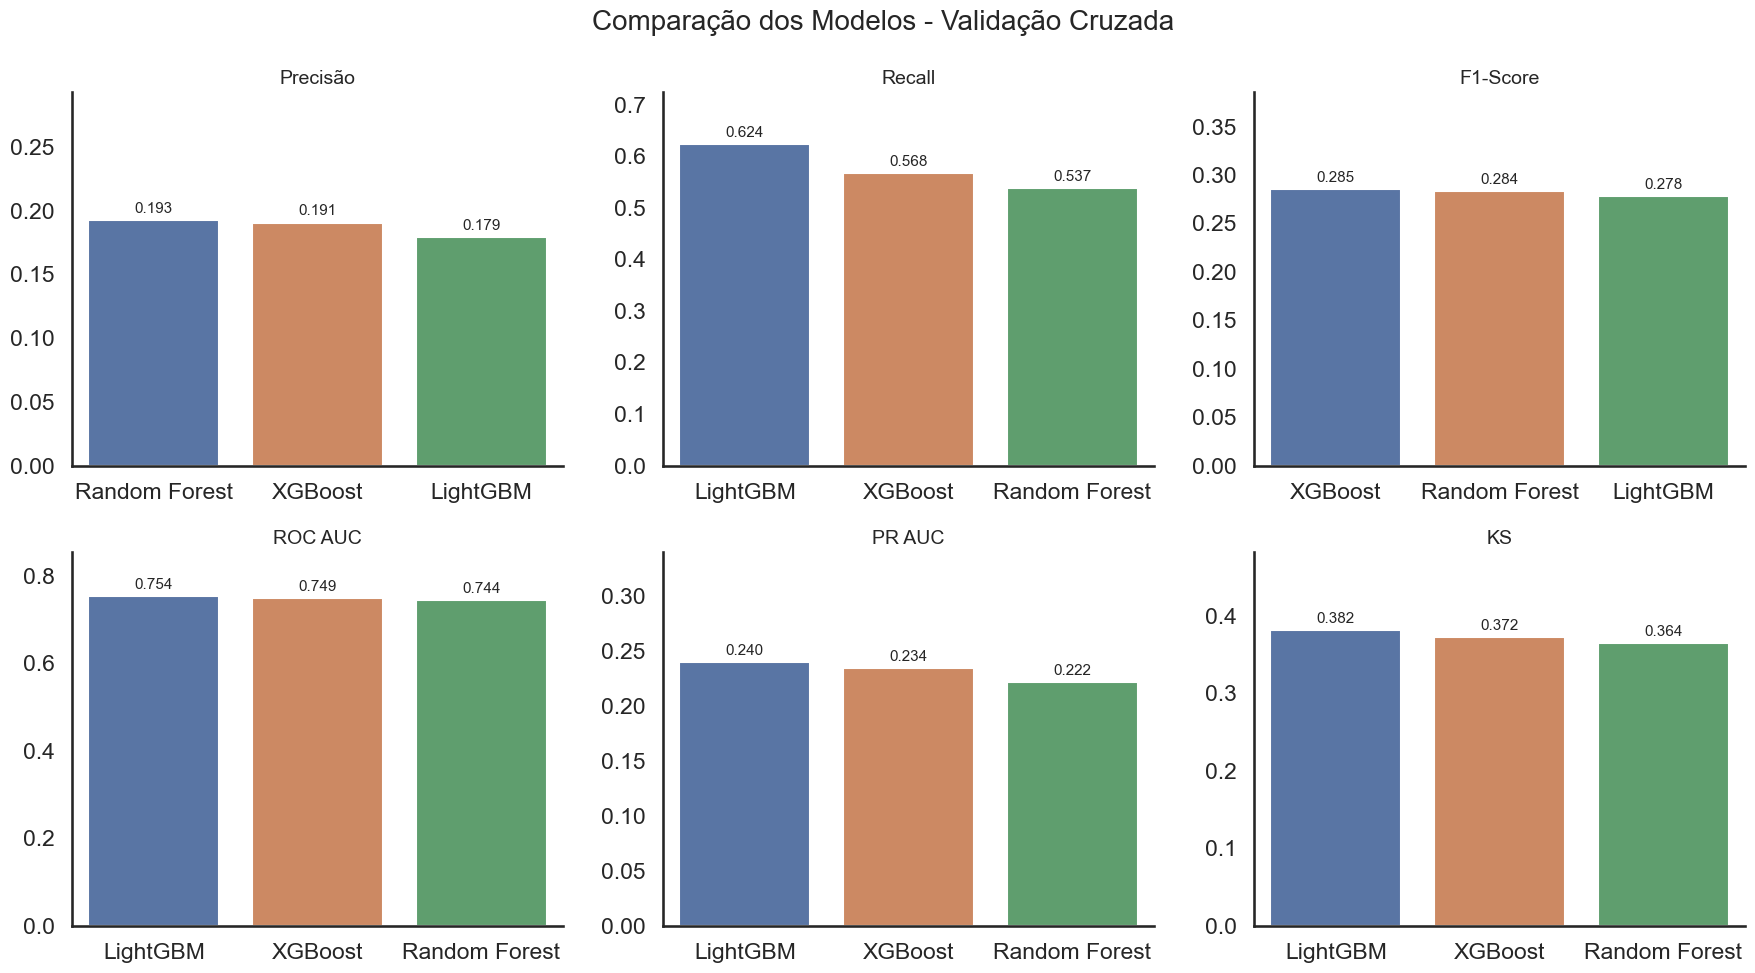

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="talk",
    palette="deep",
)

metricas = [
    ("Precision", "Precisão"),
    ("Recall", "Recall"),
    ("F1", "F1-Score"),
    ("ROC_AUC", "ROC AUC"),
    ("PR_AUC", "PR AUC"),
    ("KS", "KS"),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
)

axes = axes.flatten()

for ax, (metrica, titulo) in zip(axes, metricas):

    # Ordena os modelos do melhor para o pior
    dados_plot = resumo.sort_values(
        by=f"{metrica}_Mean",
        ascending=False,
    )

    sns.barplot(
        data=dados_plot,
        x="Modelo",
        y=f"{metrica}_Mean",
        ax=ax,
    )

    # Valores acima das barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3,
            fontsize=11,
        )

    ax.set_title(
        titulo,
        fontsize=14,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_ylim(
        0,
        min(1.0, dados_plot[f"{metrica}_Mean"].max() + 0.10)
    )

    # Remove grade
    ax.grid(False)

    # Remove bordas superior e direita
    sns.despine(ax=ax)

plt.suptitle(
    "Comparação dos Modelos - Validação Cruzada",
    fontsize=20,
)

plt.tight_layout()

plt.show()

In [67]:
import os
import mlflow
import pandas as pd
from sklearn.base import clone

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI","http://localhost:5000"))
mlflow.set_experiment("selection-model-win")

resultados = []

with mlflow.start_run(run_name="test-set-evaluation"):

    mlflow.set_tag("stage","test_evaluation")
    mlflow.set_tag("selection_metric","PR_AUC")
    mlflow.log_param("n_features",X_train_processado.shape[1])

    for nome_modelo, modelo_base in modelos.items():

        with mlflow.start_run(run_name=nome_modelo,nested=True,):

            modelo = clone(modelo_base)
            if "scale_pos_weight" in modelo.get_params():

                modelo.set_params(
                    scale_pos_weight=(
                        (y_train == 0).sum()
                        /
                        (y_train == 1).sum()
                    )
                )

            modelo.fit(X_train_processado,y_train)
            y_pred = modelo.predict(X_test_processado)
            y_prob = modelo.predict_proba(X_test_processado)[:, 1]

            metricas = calcular_metricas(y_true=y_test,y_pred=y_pred,y_prob=y_prob,)

            mlflow.log_param("algorithm",nome_modelo)
            mlflow.log_metrics({

                "precision": float(metricas["Precision"]),
                "recall": float(metricas["Recall"]),
                "f1_score": float(metricas["F1_SCORE"]),
                "roc_auc": float(metricas["ROC_AUC"]),
                "pr_auc": float(metricas["PR_AUC"]),
                "ks": float(metricas["KS"]),

            })

            resultados.append({"Modelo": nome_modelo,**metricas})

resultado_teste = (
    pd.DataFrame(resultados)
      .sort_values(
          by="PR_AUC",
          ascending=False
      )
      .reset_index(drop=True)
)

modelo_campeao = resultado_teste.loc[0, "Modelo"]
print(f"Modelo campeão: {modelo_campeao}")
resultado_teste

🏃 View run Random Forest at: http://localhost:5000/#/experiments/2/runs/7ad743cafe754961865d8d9048d97887
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run LightGBM at: http://localhost:5000/#/experiments/2/runs/9899a48432a34cb39a199dcf5ae28c28
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run XGBoost at: http://localhost:5000/#/experiments/2/runs/f8b1be9aa8b34c36a0d398fea269c222
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run test-set-evaluation at: http://localhost:5000/#/experiments/2/runs/8274a5b2f12040bc9cd010d478f47bb2
🧪 View experiment at: http://localhost:5000/#/experiments/2
Modelo campeão: LightGBM


,Modelo,Precision,Recall,F1_SCORE,ROC_AUC,PR_AUC,KS
0,LightGBM,0.176403,0.650151,0.277510,0.760272,0.251077,0.386224
1,XGBoost,0.185683,0.598187,0.283397,0.755851,0.245667,0.381598
2,Random Forest,0.189469,0.566767,0.283999,0.746979,0.226826,0.365100


In [68]:
modelos_treinados = {}

for nome, modelo in modelos.items():

    modelo = clone(modelo)

    if "scale_pos_weight" in modelo.get_params():

        scale_pos_weight = (
            (y_train == 0).sum()
            /
            (y_train == 1).sum()
        )

        modelo.set_params(scale_pos_weight=scale_pos_weight)

    modelo.fit(X_train_processado,y_train,)
    modelos_treinados[nome] = modelo

c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\eduar\AppData\Local\Temp\ipykernel_16008\4012328325.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()

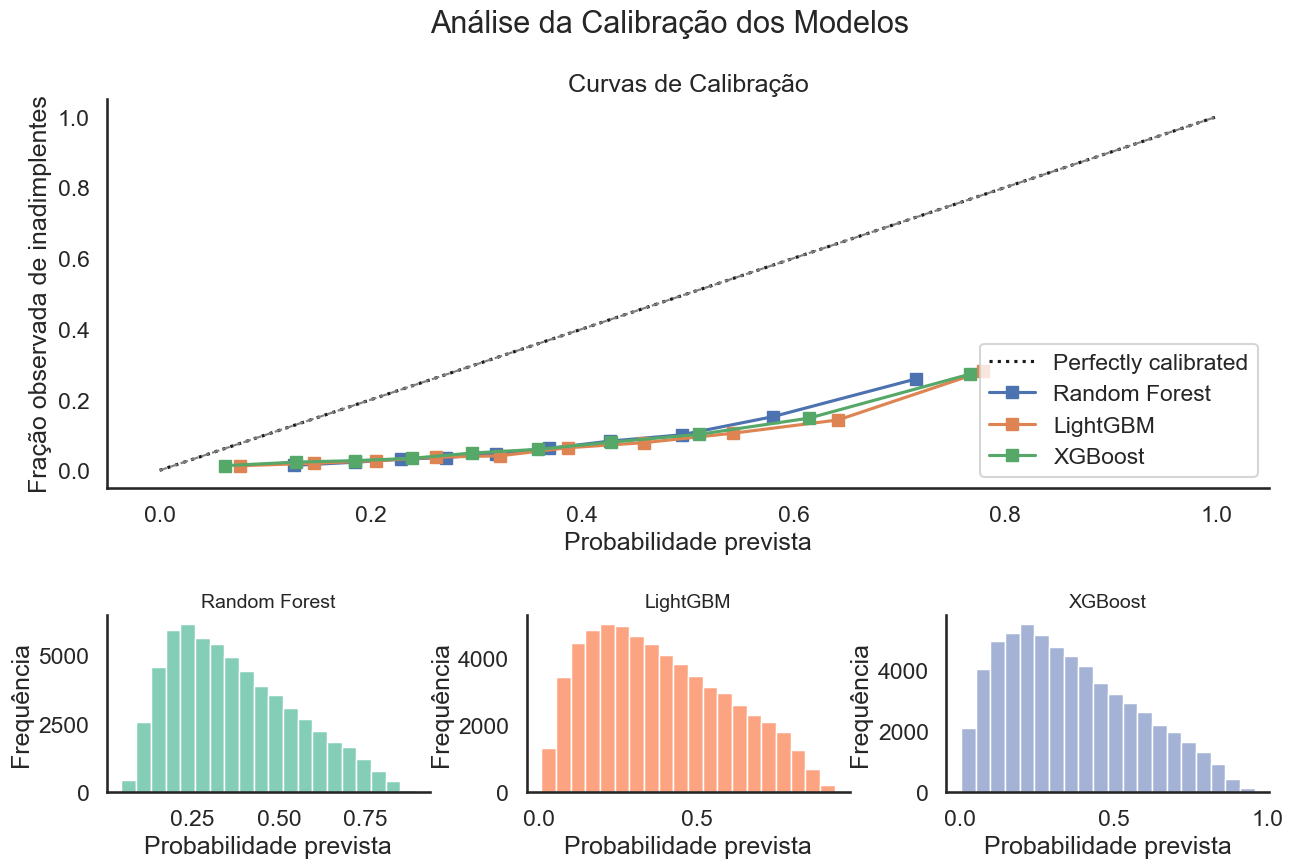


Brier Score (quanto menor, melhor):


,Modelo,Brier Score
0,Random Forest,0.165317
1,XGBoost,0.166125
2,LightGBM,0.179797


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

sns.set_theme(
    style="white",
    context="talk"
)

cores = sns.color_palette("Set2", len(modelos_treinados))

fig = plt.figure(figsize=(15, 9))

# ============================
# Layout
# ============================
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[2.2, 1],
    hspace=0.45,
    wspace=0.30,
)

# ============================
# Curvas de calibração
# ============================
ax_cal = fig.add_subplot(gs[0, :])

brier_scores = []

for cor, (nome, modelo) in zip(cores, modelos_treinados.items()):

    y_prob = modelo.predict_proba(X_test_processado)[:, 1]

    # Brier Score
    brier = brier_score_loss(
        y_test,
        y_prob,
    )

    brier_scores.append({
        "Modelo": nome,
        "Brier Score": brier,
    })

    CalibrationDisplay.from_predictions(
        y_true=y_test,
        y_prob=y_prob,
        n_bins=10,
        strategy="quantile",
        name=nome,
        ax=ax_cal,
    )

# Linha de calibração perfeita
ax_cal.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    linewidth=1.5,
)

ax_cal.set_title(
    "Curvas de Calibração",
    fontsize=18,
)

ax_cal.set_xlabel("Probabilidade prevista")
ax_cal.set_ylabel("Fração observada de inadimplentes")

ax_cal.grid(False)
sns.despine(ax=ax_cal)

# ============================
# Histogramas das probabilidades
# ============================
for i, (cor, (nome, modelo)) in enumerate(
    zip(cores, modelos_treinados.items())
):

    ax = fig.add_subplot(gs[1, i])

    y_prob = modelo.predict_proba(X_test_processado)[:, 1]

    sns.histplot(
        y_prob,
        bins=20,
        color=cor,
        alpha=0.80,
        edgecolor=None,
        ax=ax,
    )

    ax.set_title(nome, fontsize=14)
    ax.set_xlabel("Probabilidade prevista")
    ax.set_ylabel("Frequência")

    ax.grid(False)
    sns.despine(ax=ax)

# ============================
# Título geral
# ============================
plt.suptitle(
    "Análise da Calibração dos Modelos",
    fontsize=22,
)

plt.tight_layout()

plt.show()

# ============================
# Brier Score
# ============================

brier_scores = (
    pd.DataFrame(brier_scores)
    .sort_values(
        by="Brier Score",
        ascending=True,
    )
    .reset_index(drop=True)
)

print("\nBrier Score (quanto menor, melhor):")
brier_scores

**Análise**

Com base no resultado dos modelos, o lightGBM será o modelo campeão. Ele é o modelo com melhor capacidade discriminativa. Ele lidera em Recall, ROC AUC, PR AUC e KS, que são métricas centrais para avaliar a separação entre bons e maus pagadores. Como o projeto tem e premissa de um modelo que tenha uma performance maior para separar as classes, esse é o modelo escolhido. Agora, será realizado a otimização de hiperparâmetros utilizando o Optuna, usando uma abordagem multivariada. Logo depois dessa etapa, será utilizado o cálculo do threhsold para o modelo otimizado.

### Otimização de hiperparâmetros

In [88]:
import os
import mlflow
import mlflow.lightgbm
import optuna

from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score


mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000"))
mlflow.set_experiment("optimization-model-win")
mlflow.lightgbm.autolog()

# Razão entre as classes
scale_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()


def objective(trial):

    parametros = {

        "objective": "binary",
        "metric": "None",
        "verbosity": -1,
        "random_state": 42,
        "n_jobs": -1,

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),
        "n_estimators": trial.suggest_int(
            "n_estimators", 200, 2000, step=100
        ),
        "num_leaves": trial.suggest_int(
            "num_leaves", 16, 256
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 200
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.5, 1.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10, log=True
        ),
        "min_split_gain": trial.suggest_float(
            "min_split_gain", 0.0, 1.0
        ),

        # Otimização do peso da classe positiva
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            scale_pos_ratio * 0.5,
            scale_pos_ratio * 2,
            log=True,
        ),
    }

    with mlflow.start_run(
        nested=True,
        run_name=f"trial-{trial.number}",
    ):

        modelo = LGBMClassifier(**parametros)

        modelo.fit(
            X_train_processado,
            y_train,
        )

        y_prob = modelo.predict_proba(
            X_val_processado
        )[:, 1]

        pr_auc = average_precision_score(
            y_val,
            y_prob,
        )

        mlflow.log_metric(
            "validation_pr_auc",
            pr_auc,
        )

        return pr_auc


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=42,
        multivariate=True,
    ),
)

with mlflow.start_run(run_name="optuna-search"):

    study.optimize(
        objective,
        n_trials=150,
        show_progress_bar=True,
    )

    mlflow.log_params(study.best_params)
    mlflow.log_metric(
        "best_validation_pr_auc",
        study.best_value,
    )

print(study.best_value)
print(study.best_params)

c:\Users\eduar\anaconda3\Lib\site-packages\optuna\_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-07-21 15:53:56,304] A new study created in memory with name: no-name-3ff227a5-05a7-4fb3-b4d8-4c1ed5095f70


  0%|          | 0/150 [00:00<?, ?it/s]

2026/07/21 15:54:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 15:54:52 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'


🏃 View run trial-0 at: http://localhost:5000/#/experiments/3/runs/2cb17c9ab3fb42f6a309da1001231d6f
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-07-21 15:55:02,200] Trial 0 finished with value: 0.231909029430468 and parameters: {'learning_rate': 0.019906996673933378, 'n_estimators': 2000, 'num_leaves': 192, 'max_depth': 8, 'min_child_samples': 39, 'subsample': 0.662397808134481, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'min_split_gain': 0.7080725777960455, 'scale_pos_weight': 5.858354548834764}. Best is trial 0 with value: 0.231909029430468.


2026/07/21 15:55:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 15:55:48 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'


...

🏃 View run trial-147 at: http://localhost:5000/#/experiments/3/runs/7c916e1a7e7d4b44be04309d6b501d6f
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-07-21 17:17:11,259] Trial 147 finished with value: 0.23714535261904882 and parameters: {'learning_rate': 0.04199216895299991, 'n_estimators': 400, 'num_leaves': 46, 'max_depth': 4, 'min_child_samples': 131, 'subsample': 0.838425295289261, 'colsample_bytree': 0.6209429299254621, 'reg_alpha': 0.13827385194719252, 'reg_lambda': 4.006310459040347e-06, 'min_split_gain': 0.17745973872042142, 'scale_pos_weight': 16.521433048585088}. Best is trial 91 with value: 0.2411067234824961.


2026/07/21 17:17:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 17:17:44 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'


🏃 View run trial-148 at: http://localhost:5000/#/experiments/3/runs/ce2b0e6b82744bb9ab441eb5516e4bb9
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-07-21 17:17:46,425] Trial 148 finished with value: 0.24005564996478096 and parameters: {'learning_rate': 0.01074455192323162, 'n_estimators': 1900, 'num_leaves': 22, 'max_depth': 9, 'min_child_samples': 158, 'subsample': 0.9873470948039075, 'colsample_bytree': 0.5323313974507468, 'reg_alpha': 0.0016098672014329609, 'reg_lambda': 0.00018034103697845173, 'min_split_gain': 0.7339092772333528, 'scale_pos_weight': 6.29718597928158}. Best is trial 91 with value: 0.2411067234824961.


2026/07/21 17:18:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 17:18:33 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'


🏃 View run trial-149 at: http://localhost:5000/#/experiments/3/runs/bec59faddbfa49baa60c2a3653cd5dbd
🧪 View experiment at: http://localhost:5000/#/experiments/3
[I 2026-07-21 17:18:38,539] Trial 149 finished with value: 0.2377973116721291 and parameters: {'learning_rate': 0.009446226926813942, 'n_estimators': 1700, 'num_leaves': 104, 'max_depth': 10, 'min_child_samples': 13, 'subsample': 0.7137255238214322, 'colsample_bytree': 0.5751896550084875, 'reg_alpha': 1.3616356412080934, 'reg_lambda': 0.34695423888700183, 'min_split_gain': 0.6514775449062056, 'scale_pos_weight': 7.045263559450873}. Best is trial 91 with value: 0.2411067234824961.
🏃 View run optuna-search at: http://localhost:5000/#/experiments/3/runs/cceff74de09a44f48ae9e027c5f35536
🧪 View experiment at: http://localhost:5000/#/experiments/3
0.2411067234824961
{'learning_rate': 0.03328447427285721, 'n_estimators': 1500, 'num_leaves': 18, 'max_depth': 9, 'min_child_samples': 79, 'subsample': 0.9509402559744826, 'colsample_bytree

In [89]:
print(study.best_params)

{'learning_rate': 0.03328447427285721, 'n_estimators': 1500, 'num_leaves': 18, 'max_depth': 9, 'min_child_samples': 79, 'subsample': 0.9509402559744826, 'colsample_bytree': 0.5279926917649457, 'reg_alpha': 0.002958308173816128, 'reg_lambda': 6.376766128139896e-05, 'min_split_gain': 0.573024757250299, 'scale_pos_weight': 12.052912741568086}


In [90]:
from lightgbm import LGBMClassifier

modelo_final = LGBMClassifier(
    **study.best_params,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

modelo_final.set_params(
    scale_pos_weight=(
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )
)

modelo_final.fit(X_train_processado,y_train,)
y_pred = modelo_final.predict(X_test_processado)
y_prob = modelo_final.predict_proba(X_test_processado)[:, 1]

# ==========================================
# Métricas
# ==========================================

metricas = calcular_metricas(
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
)

metricas = (pd.DataFrame(metricas, index=["LightGBM"]).T)
metricas

2026/07/21 17:18:48 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9e379079e72747be9cc278ce97ad8b11', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
2026/07/21 17:19:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 17:19:18 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during lightgbm autologging: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'


🏃 View run blushing-stag-187 at: http://localhost:5000/#/experiments/3/runs/9e379079e72747be9cc278ce97ad8b11
🧪 View experiment at: http://localhost:5000/#/experiments/3


,LightGBM
Precision,0.177453
Recall,0.643907
F1_SCORE,0.278230
ROC_AUC,0.759260
PR_AUC,0.249529
KS,0.386359


c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\eduar\AppData\Local\Temp\ipykernel_16008\2104838352.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


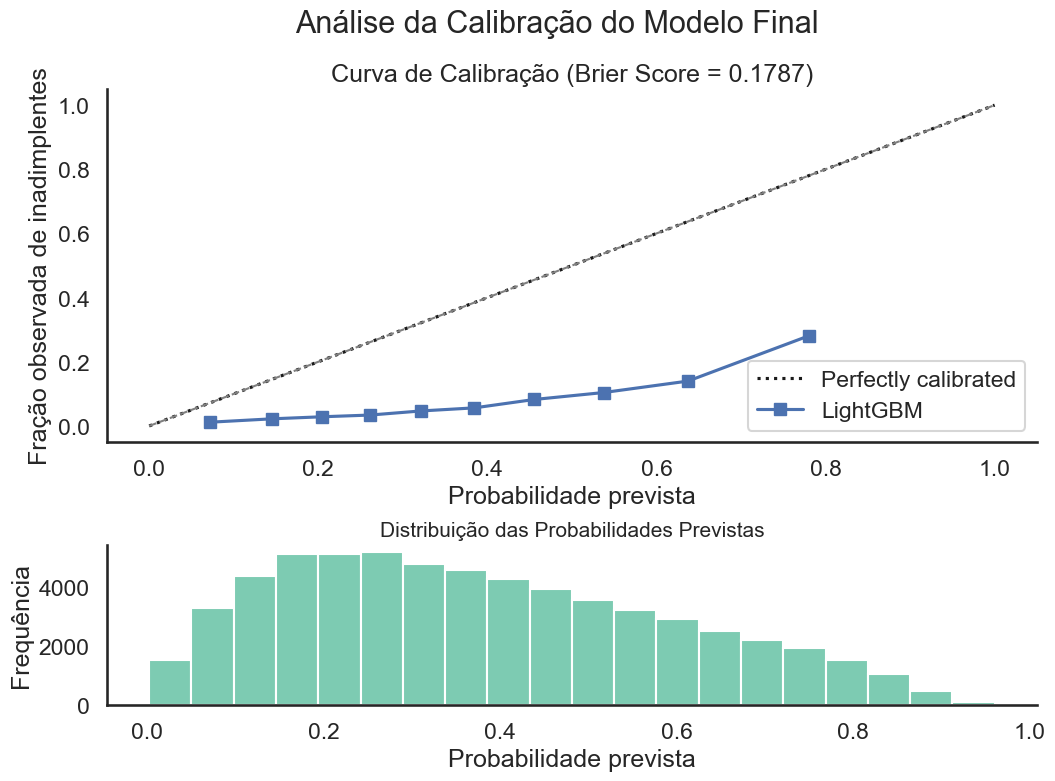

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

sns.set_theme(
    style="white",
    context="talk"
)

fig = plt.figure(figsize=(12, 8))

# ============================
# Layout
# ============================

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[2.2, 1],
    hspace=0.40,
)

# ============================
# Curva de calibração
# ============================

ax_cal = fig.add_subplot(gs[0])

CalibrationDisplay.from_predictions(
    y_true=y_test,
    y_prob=y_prob,
    n_bins=10,
    strategy="quantile",
    name="LightGBM",
    ax=ax_cal,
)

ax_cal.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    linewidth=1.5,
)

brier = brier_score_loss(
    y_test,
    y_prob,
)

ax_cal.set_title(
    f"Curva de Calibração (Brier Score = {brier:.4f})",
    fontsize=18,
)

ax_cal.set_xlabel(
    "Probabilidade prevista"
)

ax_cal.set_ylabel(
    "Fração observada de inadimplentes"
)

ax_cal.grid(False)
sns.despine(ax=ax_cal)

# ============================
# Histograma das probabilidades
# ============================

ax_hist = fig.add_subplot(gs[1])

sns.histplot(
    y_prob,
    bins=20,
    color=sns.color_palette("Set2")[0],
    alpha=0.85,
    edgecolor=None,
    ax=ax_hist,
)

ax_hist.set_title(
    "Distribuição das Probabilidades Previstas",
    fontsize=15,
)

ax_hist.set_xlabel(
    "Probabilidade prevista"
)

ax_hist.set_ylabel(
    "Frequência"
)

ax_hist.grid(False)
sns.despine(ax=ax_hist)

# ============================
# Título geral
# ============================

plt.suptitle(
    "Análise da Calibração do Modelo Final",
    fontsize=22,
)

plt.tight_layout()

plt.show()

c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

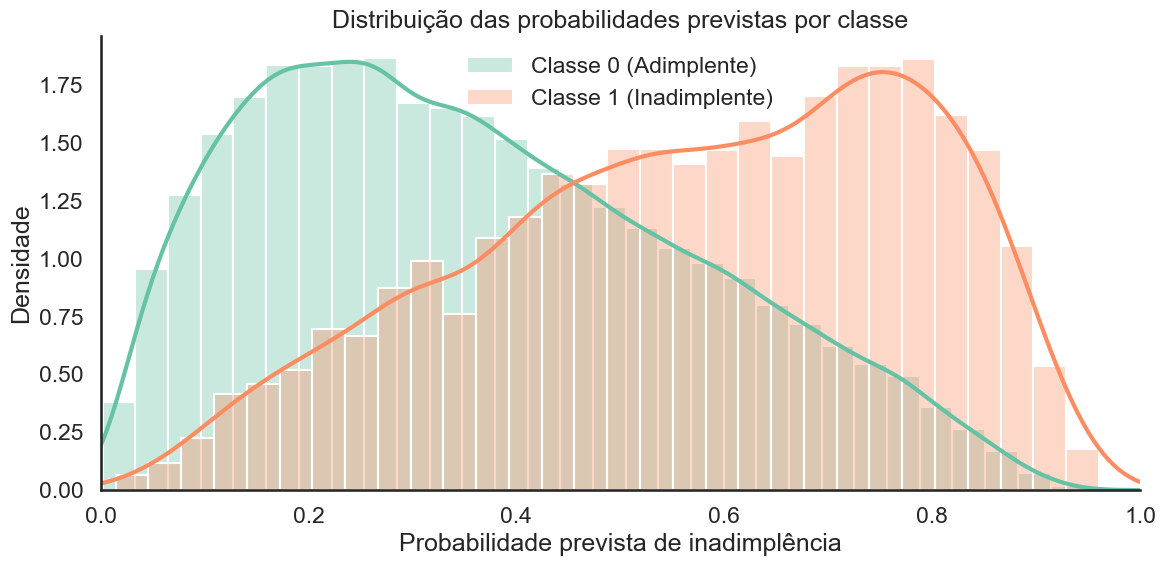

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="talk"
)

cores = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(12, 6))

# ==========================================
# Histograma - Classe 0
# ==========================================

sns.histplot(
    y_prob[y_test == 0],
    bins=30,
    stat="density",
    color=cores[0],
    alpha=0.35,
    edgecolor=None,
    label="Classe 0 (Adimplente)",
    ax=ax,
)

# KDE - Classe 0
sns.kdeplot(
    y_prob[y_test == 0],
    color=cores[0],
    linewidth=3,
    clip=(0, 1),
    ax=ax,
)

# ==========================================
# Histograma - Classe 1
# ==========================================

sns.histplot(
    y_prob[y_test == 1],
    bins=30,
    stat="density",
    color=cores[1],
    alpha=0.35,
    edgecolor=None,
    label="Classe 1 (Inadimplente)",
    ax=ax,
)

# KDE - Classe 1
sns.kdeplot(
    y_prob[y_test == 1],
    color=cores[1],
    linewidth=3,
    clip=(0, 1),
    ax=ax,
)

# ==========================================
# Configurações
# ==========================================

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Probabilidade prevista de inadimplência"
)

ax.set_ylabel(
    "Densidade"
)

ax.set_title(
    "Distribuição das probabilidades previstas por classe",
    fontsize=18,
)

ax.legend(
    frameon=False
)

ax.grid(False)

sns.despine()

plt.tight_layout()

plt.show()

### Se analisarmos apenas os 10% clientes com maior score de risco, quantas vezes mais inadimplentes encontraremos em relação à média da carteira?

In [93]:
import numpy as np
import pandas as pd

resultado = pd.DataFrame({
    "target": y_test,
    "score": y_prob,
})

# Decis (1 = maior risco)
resultado["decil"] = pd.qcut(
    resultado["score"],
    q=10,
    labels=False,
    duplicates="drop",
)

resultado["decil"] = 10 - resultado["decil"]

taxa_global = resultado["target"].mean()

lift = (
    resultado
    .groupby("decil")
    .agg(
        Clientes=("target", "count"),
        Maus=("target", "sum"),
        Taxa_Maus=("target", "mean"),
    )
    .sort_index()
)

lift["Lift"] = (
    lift["Taxa_Maus"] /
    taxa_global
)

lift["Lift Acumulado"] = (
    lift["Maus"].cumsum()
    /
    lift["Clientes"].cumsum()
) / taxa_global

lift = lift.round(3)

lift

,Clientes,Maus,Taxa_Maus,Lift,Lift Acumulado
decil,,,,,
1,6151,1728,0.281,3.480,3.480
2,6150,860,0.140,1.732,2.606
3,6150,641,0.104,1.291,2.168
4,6150,508,0.083,1.023,1.882
5,6150,347,0.056,0.699,1.645
6,6151,287,0.047,0.578,1.467
7,6150,209,0.034,0.421,1.318
8,6150,176,0.029,0.354,1.197
9,6150,137,0.022,0.276,1.095


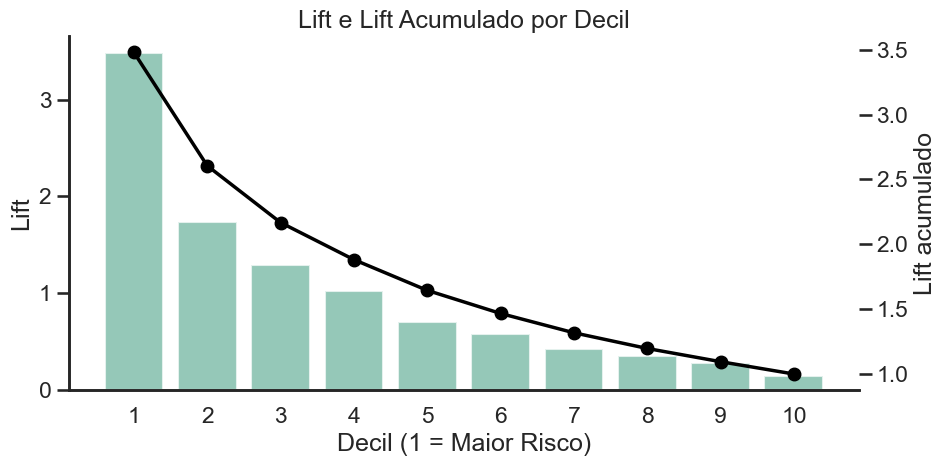

In [94]:
fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=lift.reset_index(),
    x="decil",
    y="Lift",
    color=sns.color_palette("Set2")[0],
    alpha=0.75,
    ax=ax,
)

ax2 = ax.twinx()

ax2.plot(
    lift.index.astype(str),
    lift["Lift Acumulado"],
    marker="o",
    linewidth=2.5,
    color="black",
)

ax.set_ylabel("Lift")
ax2.set_ylabel("Lift acumulado")

ax.set_xlabel("Decil (1 = Maior Risco)")

ax.set_title(
    "Lift e Lift Acumulado por Decil",
    fontsize=18,
)

sns.despine()

plt.tight_layout()

plt.show()

O primeiro decil apresentou Lift igual a 3,48, indicando que a concentração de inadimplentes entre os 10% clientes com maior score é 3,48 vezes superior à taxa média de inadimplência da carteira. Esse resultado demonstra que o modelo possui boa capacidade de ordenação do risco, concentrando a maior parte dos eventos nas primeiras posições do ranking.

In [95]:
import pandas as pd

def tabela_decis(y_true, y_prob):
    df = pd.DataFrame({
        "target": y_true,
        "score": y_prob
    })

    df = df.sort_values("score", ascending=False)

    df["decil"] = pd.qcut(
        df.index,
        10,
        labels=False
    ) + 1

    resumo = (
        df.groupby("decil")
        .agg(
            taxa_eventos=("target", "mean"),
            quantidade=("target", "size"),
            eventos=("target", "sum")
        )
        .reset_index()
    )

    resumo["taxa_eventos"] *= 100

    return resumo

In [96]:
y_prob_train = modelo_final.predict_proba(X_train_processado)[:, 1]
y_prob_test = modelo_final.predict_proba(X_test_processado)[:, 1]

In [97]:
treino = tabela_decis(y_train, y_prob_train)
teste = tabela_decis(y_test, y_prob_test)

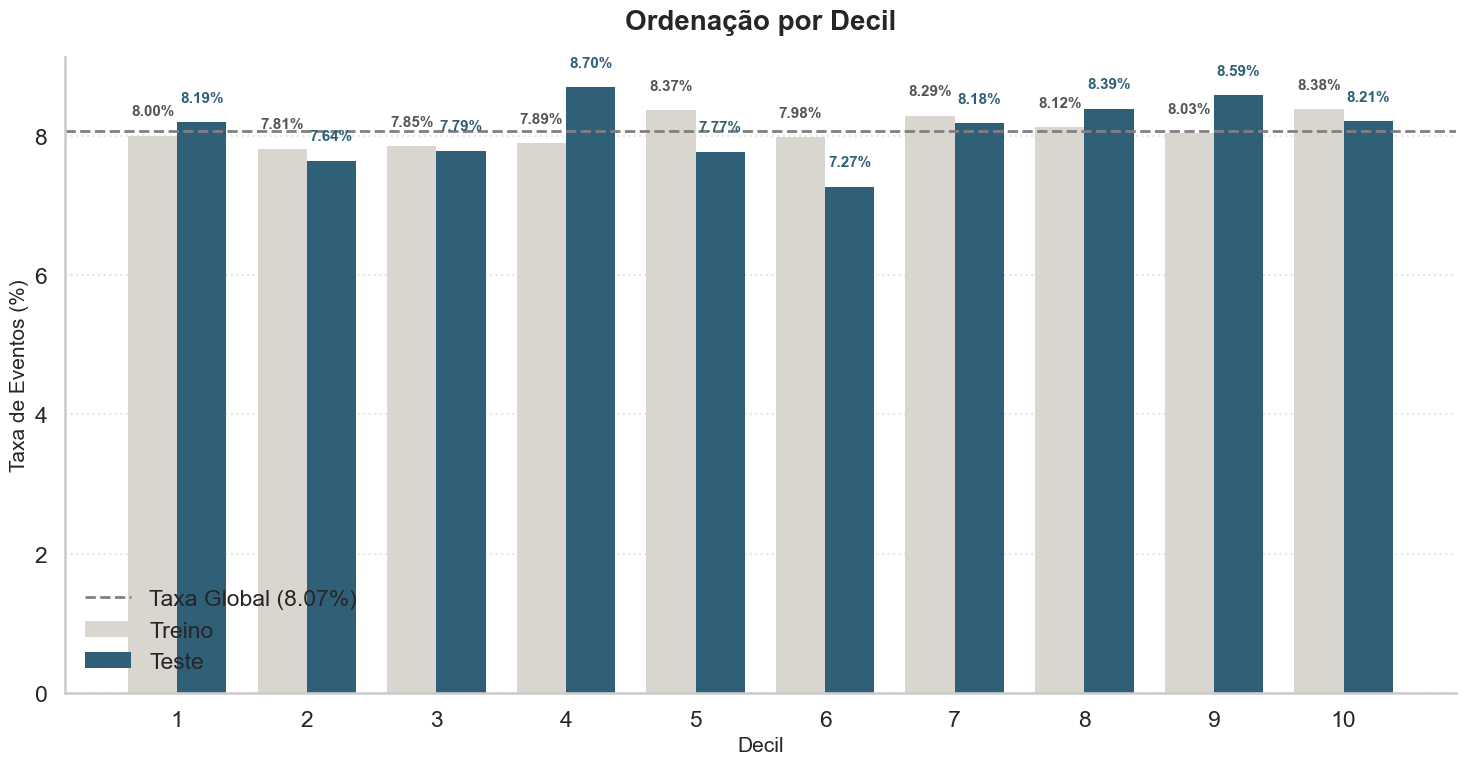

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk"
)

fig, ax = plt.subplots(figsize=(15, 8))

cores = ["#d9d6cf", "#2f6078"]

x = np.arange(len(treino))
width = 0.38

bars_train = ax.bar(
    x - width/2,
    treino["taxa_eventos"],
    width,
    color=cores[0],
    label="Treino",
    edgecolor="none"
)

bars_test = ax.bar(
    x + width/2,
    teste["taxa_eventos"],
    width,
    color=cores[1],
    label="Teste",
    edgecolor="none"
)

# Valores sobre as barras
for bar in bars_train:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.25,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#555555",
        fontweight="bold"
    )

for bar in bars_test:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.25,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=cores[1],
        fontweight="bold"
    )

taxa_global = y_train.mean() * 100

ax.axhline(
    taxa_global,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Taxa Global ({taxa_global:.2f}%)"
)

ax.set_xticks(x)
ax.set_xticklabels(np.arange(1,11))

ax.set_xlabel("Decil", fontsize=15)
ax.set_ylabel("Taxa de Eventos (%)", fontsize=15)

ax.set_title(
    "Ordenação por Decil",
    fontsize=20,
    weight="bold",
    pad=20
)

ax.legend(frameon=False)
sns.despine()
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [100]:
import numpy as np

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)

# Probabilidades na validação
y_prob_val = modelo_final.predict_proba(X_val_processado)[:, 1]

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_prob_val,
)

# F1 para cada threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    /
    (precision[:-1] + recall[:-1] + 1e-12)
)

# Melhor threshold
idx_best = np.argmax(f1_scores)

best_threshold = thresholds[idx_best]
best_f1 = f1_scores[idx_best]

print(f"Threshold ótimo: {best_threshold:.4f}")
print(f"F1 máximo na validação: {best_f1:.4f}")

Threshold ótimo: 0.6151
F1 máximo na validação: 0.3006


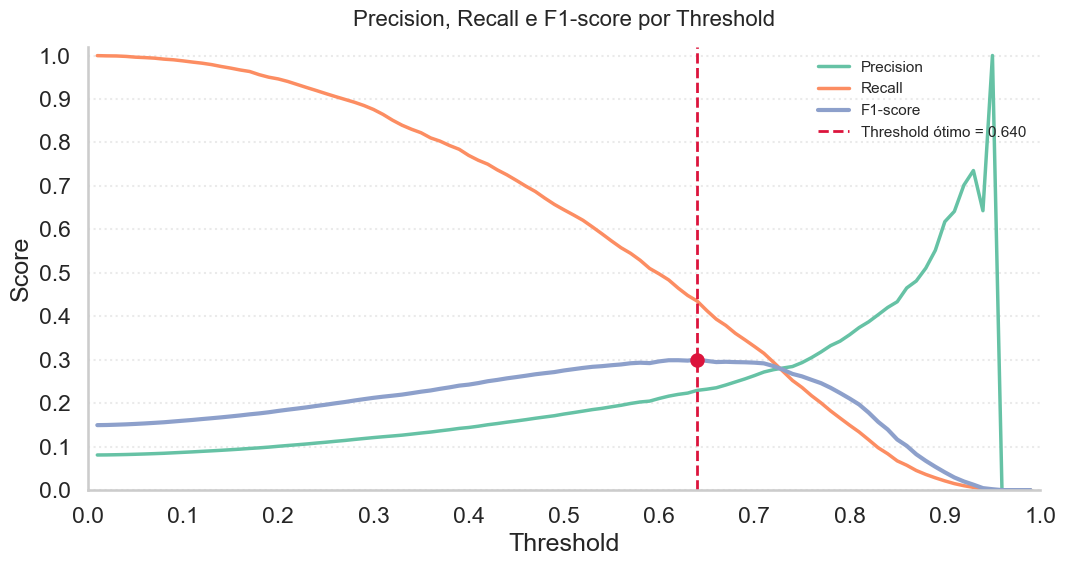

Threshold ótimo: 0.6400
F1 máximo: 0.3004


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MultipleLocator
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

# ============================
# Configuração do gráfico
# ============================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# ============================
# Probabilidades da validação
# ============================

y_prob_val = modelo_final.predict_proba(X_val_processado)[:, 1]

# ============================
# Avaliação para vários thresholds
# ============================

thresholds = np.linspace(0.01, 0.99, 99)

precision = []
recall = []
f1 = []

for threshold in thresholds:

    y_pred = (y_prob_val >= threshold).astype(int)

    precision.append(
        precision_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    recall.append(
        recall_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    f1.append(
        f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)

# ============================
# Melhor threshold
# ============================

idx_best = np.argmax(f1)

best_threshold = thresholds[idx_best]
best_f1 = f1[idx_best]

# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11, 6))

cores = sns.color_palette("Set2", 3)

ax.plot(
    thresholds,
    precision,
    linewidth=2.5,
    color=cores[0],
    label="Precision"
)

ax.plot(
    thresholds,
    recall,
    linewidth=2.5,
    color=cores[1],
    label="Recall"
)

ax.plot(
    thresholds,
    f1,
    linewidth=3,
    color=cores[2],
    label="F1-score"
)

# Threshold ótimo

ax.axvline(
    best_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Threshold ótimo = {best_threshold:.3f}"
)

ax.scatter(
    best_threshold,
    best_f1,
    s=80,
    color="crimson",
    zorder=5
)

# Configurações

ax.set_title(
    "Precision, Recall e F1-score por Threshold",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

ax.grid(
    axis="x",
    visible=False
)

sns.despine()

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

print(f"Threshold ótimo: {best_threshold:.4f}")
print(f"F1 máximo: {best_f1:.4f}")

2026/07/21 19:06:21 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\eduar\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
c:\Users\eduar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will b

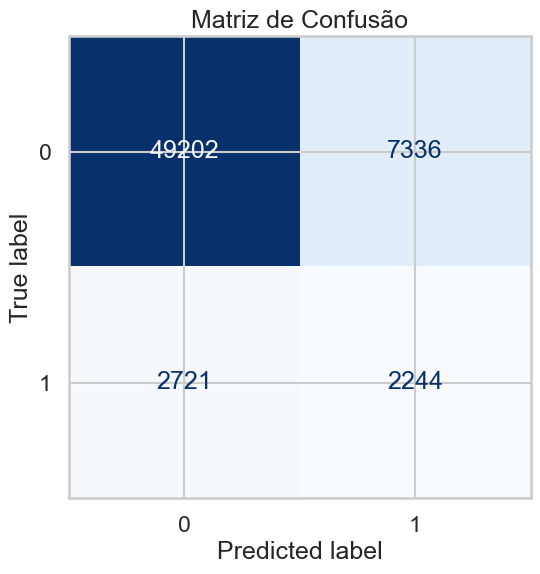

c:\Users\eduar\anaconda3\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


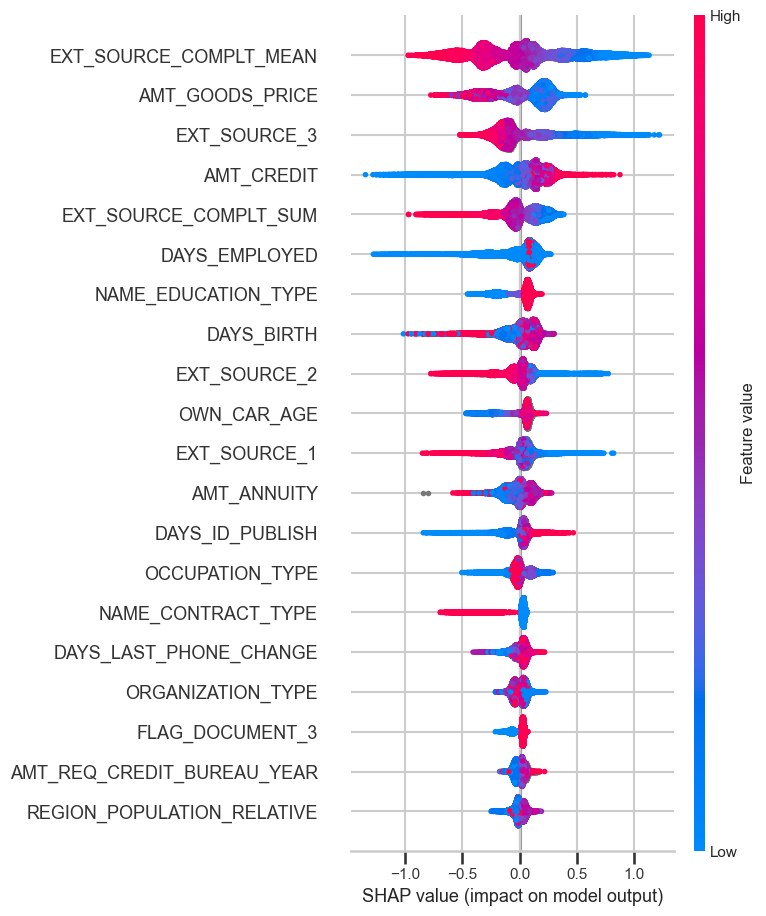

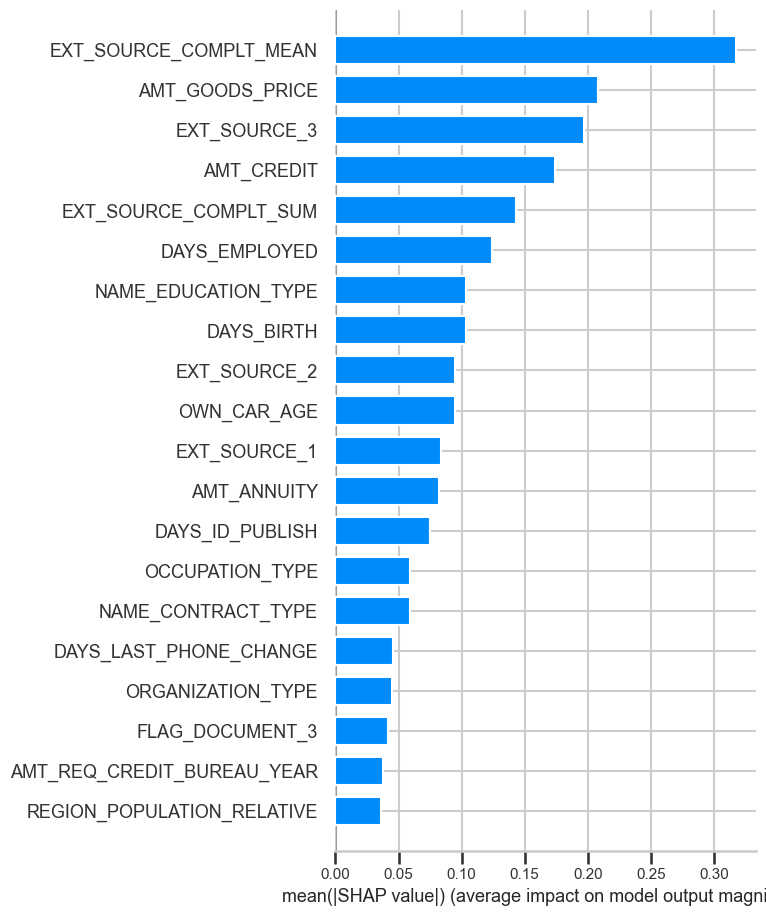

2026/07/21 19:08:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 19:09:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run champion-model at: http://localhost:5000/#/experiments/4/runs/0e8e23708da1498e92539cb5473e1535
🧪 View experiment at: http://localhost:5000/#/experiments/4
MÉTRICAS FINAIS
Threshold: 0.6400
Precision: 0.2342
Recall:    0.4520
F1-score:  0.3086
PR-AUC:    0.2488
ROC-AUC:   0.7596
KS:        0.3835


In [108]:
import os
import mlflow
import mlflow.sklearn
import shap
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
)

# ======================================================
# MLflow
# ======================================================

mlflow.set_tracking_uri(
    os.getenv(
        "MLFLOW_TRACKING_URI",
        "http://localhost:5000"
    )
)

mlflow.set_experiment("final-model")

# Como o modelo será registrado manualmente,
# desabilitamos o log automático do modelo
mlflow.sklearn.autolog(
    log_models=False,
    log_input_examples=True,
    log_model_signatures=True,
)

# ======================================================
# Modelo campeão
# ======================================================

modelo_final = LGBMClassifier(
    **study.best_params,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

# ======================================================
# Pipeline
# ======================================================

pipeline = Pipeline(
    steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo_final),
    ]
)

# ======================================================
# Treinamento
# ======================================================

with mlflow.start_run(run_name="champion-model"):

    # ==========================================
    # Tags
    # ==========================================

    mlflow.set_tag("stage", "production")
    mlflow.set_tag("model_role", "champion")

    # ==========================================
    # Fit
    # ==========================================

    pipeline.fit(
        X_train,
        y_train,
    )

    # ==========================================
    # Avaliação
    # ==========================================

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Threshold encontrado na validação
    y_pred = (
        y_prob >= best_threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
    )

    recall = recall_score(
        y_test,
        y_pred,
    )

    f1 = f1_score(
        y_test,
        y_pred,
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob,
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
    )

    metricas = calcular_metricas(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
    )

    # ==========================================
    # Log métricas
    # ==========================================

    mlflow.log_metrics({

        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "ks": metricas["KS"],

    })

    # Threshold é parâmetro
    mlflow.log_param(
        "decision_threshold",
        float(best_threshold)
    )

    # ==========================================
    # Classification Report
    # ==========================================

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
    )

    mlflow.log_dict(
        report,
        "classification_report.json"
    )

    # ==========================================
    # Matriz de Confusão
    # ==========================================

    fig, ax = plt.subplots(figsize=(6, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title("Matriz de Confusão")

    mlflow.log_figure(
        fig,
        "confusion_matrix.png"
    )

    plt.show()
    plt.close(fig)

    # ==========================================
    # SHAP
    # ==========================================

    X_test_transformado = (
        pipeline
        .named_steps["preprocessador"]
        .transform(X_test)
    )

    modelo = (
        pipeline
        .named_steps["modelo"]
    )

    feature_names = (
        pipeline
        .named_steps["preprocessador"]
        .get_feature_names_out()
    )

    explainer = shap.TreeExplainer(
        modelo
    )

    shap_values = explainer.shap_values(
        X_test_transformado,
        check_additivity=False,
    )

    # Compatibilidade versões SHAP
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    # ==========================================
    # SHAP Summary
    # ==========================================

    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values_plot,
        X_test_transformado,
        feature_names=feature_names,
        show=False,
    )

    plt.tight_layout()

    mlflow.log_figure(
        plt.gcf(),
        "shap_summary.png",
    )

    plt.show()
    plt.close()

    # ==========================================
    # SHAP Importance
    # ==========================================

    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values_plot,
        X_test_transformado,
        feature_names=feature_names,
        plot_type="bar",
        max_display=20,
        show=False,
    )

    plt.tight_layout()

    mlflow.log_figure(
        plt.gcf(),
        "shap_importance.png",
    )

    plt.show()
    plt.close()

    # ==========================================
    # Registro do Modelo
    # ==========================================

    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="champion",
    )

# ======================================================
# Resultados
# ======================================================

print("=" * 50)
print("MÉTRICAS FINAIS")
print("=" * 50)

print(f"Threshold: {best_threshold:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"KS:        {metricas['KS']:.4f}")